In [10]:
import os
import glob
import math
import numpy as np
import pandas as pd
from typing import List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [11]:
# ======================= PATHS =======================
DATA_ROOT = r"C:\transformer_nikhil_demo\Nikhil_data_Transformer\data_merged_two_hand"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR  = os.path.join(DATA_ROOT, "test")
VAL_DIR   = os.path.join(DATA_ROOT, "val") 


MODEL_SAVE_PATH     = r"C:\transformer_nikhil_demo\test_new_data_model"
LABEL_MAP_SAVE_PATH = r"C:\transformer_nikhil_demo\label_map\label_map_days_twohand.txt"
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
os.makedirs(os.path.dirname(LABEL_MAP_SAVE_PATH), exist_ok=True)

In [12]:
# ======================= HYPERPARAMS =======================
MAX_SEQ_LEN = 59           # based on your CSVs
FEATURE_DIM = 126          # 127 cols - 1 label column
D_MODEL     = 256
N_HEAD      = 8
NUM_LAYERS  = 6
FFN_DIM     = 1024
DROPOUT     = 0.3

BATCH_SIZE  = 32
NUM_EPOCHS  = 50
LR          = 1e-4
VAL_SPLIT   = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [13]:
# Cell 2 (Modified): Analyze and inspect CSV files

def load_all_csv_paths(root_dir: str) -> List[str]:
    pattern = os.path.join(root_dir, "**", "*.csv")
    paths = glob.glob(pattern, recursive=True)
    return paths

# Load paths from separate directories
train_paths = load_all_csv_paths(TRAIN_DIR)
val_paths   = load_all_csv_paths(VAL_DIR)
test_paths  = load_all_csv_paths(TEST_DIR)

all_paths = train_paths + val_paths + test_paths

print(f"Found {len(train_paths)} training CSV files")
print(f"Found {len(val_paths)} validation CSV files")
print(f"Found {len(test_paths)} test CSV files")
print(f"Total: {len(all_paths)} CSV files")

# Collect shapes and labels
seq_lengths = []
labels = set()

for path in all_paths[:10]:  # sample first 10 for print
    df = pd.read_csv(path)
    seq_len, num_cols = df.shape
    
    label_name = df.columns[0]               # first column header is label
    labels.add(label_name)
    
    seq_lengths.append(seq_len)
    
    numeric = df.iloc[:, 1:]
    min_val = numeric.min().min()
    max_val = numeric.max().max()
    
    print(f"{os.path.basename(path)}: shape={df.shape}, label={label_name}, "
          f"numeric min={min_val:.4f}, max={max_val:.4f}")

print("\nUnique labels found:", sorted(labels))
print("Sequence lengths: min =", min(seq_lengths), 
      "max =", max(seq_lengths), "avg =", sum(seq_lengths)/len(seq_lengths))

Found 3066 training CSV files
Found 1020 validation CSV files
Found 1020 test CSV files
Total: 5106 CSV files
Friday_1.csv: shape=(79, 127), label=Friday, numeric min=-0.0517, max=1.0312
Friday_10.csv: shape=(60, 127), label=Friday, numeric min=-0.1024, max=0.8291
Friday_10_Akshata.csv: shape=(75, 127), label=Friday, numeric min=-0.0717, max=0.6721
Friday_10_Gayatri.csv: shape=(90, 127), label=Friday, numeric min=-0.0703, max=0.6980
Friday_10_Geethika.csv: shape=(91, 127), label=Friday, numeric min=-0.0881, max=0.7436
Friday_10_Nikhil.csv: shape=(90, 127), label=Friday, numeric min=-0.1409, max=0.8237
Friday_10_Pranay.csv: shape=(48, 127), label=Friday, numeric min=-0.1573, max=0.9682
Friday_10_Pranjali_Maam_Pranjali_Maam.csv: shape=(59, 127), label=Friday, numeric min=-0.0521, max=0.6267
Friday_10_Prasanjeet.csv: shape=(59, 127), label=Friday, numeric min=-0.1216, max=0.8958
Friday_10_Prasanjeet_Prasanjeet.csv: shape=(59, 127), label=Friday, numeric min=-0.1302, max=0.8954

Unique lab

In [14]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from typing import List, Dict

# ===============================
# 4.1 Build label mapping
# ===============================
def get_label_set(paths: List[str]) -> List[str]:
    labels = set()
    for p in paths:
        df = pd.read_csv(p, nrows=1)
        label = df.columns[0]   # label stored as first column name
        labels.add(label)
    return sorted(labels)

all_label_names = get_label_set(all_paths)
num_classes = len(all_label_names)

print("Detected labels:", all_label_names)
print("Number of classes:", num_classes)

label2idx = {lbl: i for i, lbl in enumerate(all_label_names)}
idx2label = {i: lbl for lbl, i in label2idx.items()}

Detected labels: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Number of classes: 7


In [15]:
def pad_or_truncate(seq: torch.Tensor, max_len: int) -> torch.Tensor:
    """
    seq: [T, F]
    """
    T, F = seq.shape

    if T > max_len:
        return seq[:max_len]
    elif T < max_len:
        pad_len = max_len - T
        pad = torch.zeros((pad_len, F), dtype=seq.dtype)
        return torch.cat([seq, pad], dim=0)
    else:
        return seq
class SignCSVDataset(Dataset):
    def __init__(
        self,
        csv_paths: List[str],
        max_seq_len: int,
        feature_dim: int,
        label2idx: Dict[str, int]
    ):
        self.paths = csv_paths
        self.max_seq_len = max_seq_len
        self.feature_dim = feature_dim
        self.label2idx = label2idx

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        df = pd.read_csv(path)

        # Label
        label_name = df.columns[0]
        if label_name not in self.label2idx:
            raise ValueError(f"Unknown label '{label_name}' in {path}")

        label_idx = self.label2idx[label_name]

        # Features (all except first column)
        numeric = df.iloc[:, 1:].astype(np.float32).values
        seq = torch.from_numpy(numeric)

        # Feature dimension check
        if seq.shape[1] != self.feature_dim:
            raise ValueError(
                f"Feature dim mismatch in {path}: "
                f"got {seq.shape[1]}, expected {self.feature_dim}"
            )

        seq = pad_or_truncate(seq, self.max_seq_len)

        return seq, label_idx


In [16]:
# Cell 7 (Modified): Create datasets and dataloaders

# Keep the pad_or_truncate and SignCSVDataset classes as they are (from your original code)

# Create datasets - NO TRAIN_TEST_SPLIT needed anymore
print(f"Train CSVs: {len(train_paths)}, Val CSVs: {len(val_paths)}, Test CSVs: {len(test_paths)}")

train_dataset = SignCSVDataset(train_paths, MAX_SEQ_LEN, FEATURE_DIM, label2idx)
val_dataset   = SignCSVDataset(val_paths,   MAX_SEQ_LEN, FEATURE_DIM, label2idx)
test_dataset  = SignCSVDataset(test_paths,  MAX_SEQ_LEN, FEATURE_DIM, label2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Quick sanity check: one batch
batch_x, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_x.shape)   # [B, T, F]
print("Batch y shape:", batch_y.shape)   # [B]


Train CSVs: 3066, Val CSVs: 1020, Test CSVs: 1020
Batch X shape: torch.Size([32, 59, 126])
Batch y shape: torch.Size([32])


In [17]:
# ======================= MODEL =======================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 70):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SignTransformerEncoder(nn.Module):
    def __init__(self,
                 feature_dim,
                 d_model,
                 nhead,
                 num_layers,
                 ffn_dim,
                 num_classes,
                 dropout,
                 max_seq_len):
        super().__init__()

        self.input_proj = nn.Linear(feature_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(d_model, num_classes)

    def forward(self, x):          # x: [B, T, F]
        x = self.input_proj(x)     # [B, T, D]
        x = self.pos_encoder(x)    # [B, T, D]
        x = self.encoder(x)        # [B, T, D]
        x = x.mean(dim=1)          # [B, D]
        x = self.dropout(x)
        return self.fc_out(x)      # [B, C]


model = SignTransformerEncoder(
    FEATURE_DIM,
    D_MODEL,
    N_HEAD,
    NUM_LAYERS,
    FFN_DIM,
    num_classes,
    DROPOUT,
    MAX_SEQ_LEN,
).to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

SignTransformerEncoder(
  (input_proj): Linear(in_features=126, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=256, out_features=7, bias=True)
)


In [ ]:
# ======================= TRAINING LOOP =======================

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # Disable gradients during validation
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            if train:
                optimizer.zero_grad()

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == batch_y).sum().item()
            total_samples += batch_x.size(0)

    avg_loss = total_loss / max(total_samples, 1)
    avg_acc  = total_correct / max(total_samples, 1)

    return avg_loss, avg_acc


# ======================= TRAIN =======================

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state_dict = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()


# ======================= LOAD BEST MODEL =======================

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print("✅ Best model loaded (saving handled in next cell)")


Epoch 01/50 | Train loss: 1.7630, acc: 0.2554 | Val loss: 1.4708, acc: 0.3392
Epoch 02/50 | Train loss: 1.4394, acc: 0.3855 | Val loss: 1.1653, acc: 0.5108
Epoch 03/50 | Train loss: 1.0046, acc: 0.5917 | Val loss: 0.6573, acc: 0.7314
Epoch 04/50 | Train loss: 0.6419, acc: 0.7528 | Val loss: 0.4754, acc: 0.8157
Epoch 05/50 | Train loss: 0.4894, acc: 0.8128 | Val loss: 0.4032, acc: 0.8696
Epoch 06/50 | Train loss: 0.4647, acc: 0.8327 | Val loss: 0.2959, acc: 0.9078
Epoch 07/50 | Train loss: 0.2607, acc: 0.9090 | Val loss: 0.3304, acc: 0.8637
Epoch 08/50 | Train loss: 0.1894, acc: 0.9400 | Val loss: 0.3212, acc: 0.8775
Epoch 09/50 | Train loss: 0.2067, acc: 0.9305 | Val loss: 0.1606, acc: 0.9382
Epoch 10/50 | Train loss: 0.1610, acc: 0.9455 | Val loss: 0.3214, acc: 0.8775
Epoch 11/50 | Train loss: 0.1777, acc: 0.9423 | Val loss: 0.2571, acc: 0.9167
Epoch 12/50 | Train loss: 0.1799, acc: 0.9374 | Val loss: 0.2945, acc: 0.8980
Epoch 13/50 | Train loss: 0.1920, acc: 0.9335 | Val loss: 0.1206


Used class indices: [0, 1, 2, 3, 4, 5, 6]

Classification report:

              precision    recall  f1-score   support

      Friday       1.00      0.59      0.74        70
      Monday       0.71      0.86      0.78        70
    Saturday       0.92      0.34      0.50        70
      Sunday       0.53      1.00      0.69        40
    Thursday       0.56      1.00      0.72        70
     Tuesday       0.93      1.00      0.97        70
   Wednesday       1.00      0.49      0.65        70

    accuracy                           0.74       460
   macro avg       0.81      0.75      0.72       460
weighted avg       0.83      0.74      0.72       460


Confusion matrix:
 [[41 22  2  0  0  5  0]
 [ 0 60  0 10  0  0  0]
 [ 0  0 24  0 46  0  0]
 [ 0  0  0 40  0  0  0]
 [ 0  0  0  0 70  0  0]
 [ 0  0  0  0  0 70  0]
 [ 0  2  0 26  8  0 34]]


<Figure size 800x600 with 0 Axes>

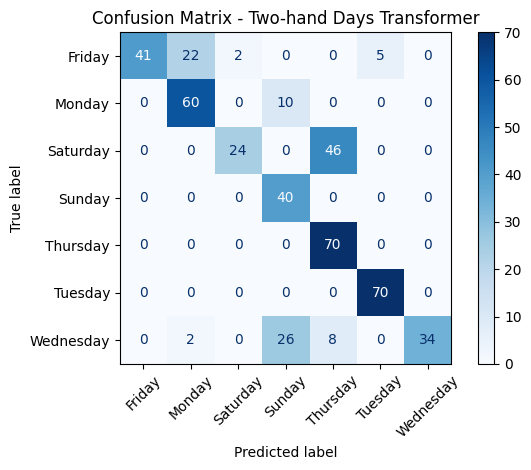

In [ ]:
# ======================= FINAL TEST EVAL =======================
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        logits = model(batch_x)
        preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nUsed class indices:", sorted(set(all_labels.tolist())))

target_names = [idx2label[i] for i in range(num_classes)]
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds,
                            labels=list(range(num_classes)),
                            target_names=target_names,
                            zero_division=0))

cm = confusion_matrix(all_labels, all_preds,
                      labels=list(range(num_classes)))
print("\nConfusion matrix:\n", cm)

# ---- Confusion matrix visualization ----
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot(xticks_rotation=45, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix - Two-hand Days Transformer")
plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
# Corrected (file path) - use a .pth or .pt extension
MODEL_DIR = r"C:\transformer_nikhil_demo\test_new_data_model"
SAVE_PATH = os.path.join(MODEL_DIR, "dual_hand_model_num_head_8_1024_LR_enc_6_epcohs_50.pth") # Or "model.pt"

# Ensure directory exists
torch.save(model.state_dict(), SAVE_PATH)

print(f"✅ Model saved at:\n{SAVE_PATH}")

✅ Model saved at:
C:\Users\nikhi\Desktop\CDAC_Nikhil\models\test_new_data_model\dual_hand_model_num_head_8_512_LR_enc_4_epcohs_50.pth
